<div style="display: flex; align-items: center; width: 100%;">
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../../utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Entropy Estimation
    </h1>
  </div>
</div>

Entropy measures how unpredictable a series is, and it is the building block for
information-theoretic features (e.g. the entropy of a price-change message). The
textbook **plug-in** (maximum-likelihood) estimator simply plugs the observed
symbol frequencies into Shannon's formula. The catch: symbols you never observed
contribute zero, so the plug-in **systematically underestimates** entropy by about
$-(K-1)/(2N)$, a bias that grows with the alphabet size $K$ and shrinks with the
sample $N$. When the counts are **undersampled** (a large effective alphabet
relative to the sample) the plug-in is badly biased.

Three bias-corrected estimators add the missing mass back: **Miller-Madow** (a
cheap first-order fix), **Grassberger** (a higher-order correction), and **NSB**
(a Bayesian posterior mean over a near-uniform-entropy prior). We show all three
recover the truth where the plug-in cannot, and that they converge to the plug-in
when the sample is large.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# --- Local source bootstrap -------------------------------------------------
# The admitted Stage-1 methods demonstrated here are merged in the RiskLabAI.py
# source tree but not yet in a tagged PyPI release, so we put the local source
# ahead of any installed copy. Once these ship in a release this block is a
# no-op and a plain `pip install RiskLabAI` is enough.
import sys
from pathlib import Path
_cands = [p / "RiskLabAI.py" for p in [Path.cwd(), *Path.cwd().parents]]
_cands.append(Path(r"C:/risklab/risklabai/RiskLabAI.py"))
for _src in _cands:
    if (_src / "RiskLabAI" / "__init__.py").exists():
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({  # theme-adaptive figures: transparent bg + neutral-gray foreground
    "figure.facecolor": "none", "axes.facecolor": "none",
    "savefig.facecolor": "none", "savefig.transparent": True,
    "text.color": "#888888", "axes.labelcolor": "#888888", "axes.titlecolor": "#888888",
    "axes.edgecolor": "#888888", "xtick.color": "#888888", "ytick.color": "#888888",
    "grid.color": "#888888", "grid.alpha": 0.3, "legend.framealpha": 0.0,
})


In [2]:
from RiskLabAI.features.entropy_features import (
    plug_in_entropy_estimator,   # baseline: maximum-likelihood (plug-in) entropy
    miller_madow_entropy,        # first-order bias correction
    grassberger_entropy,         # higher-order bias correction
    nsb_entropy,                 # Nemenman-Shafee-Bialek Bayesian estimator
)

def random_message(alphabet_size, length, seed):
    """An i.i.d. uniform draw over `alphabet_size` symbols; true entropy = log2(K) bits."""
    rng = np.random.default_rng(seed)
    alpha = "0123456789abcdefghijklmnopqrstuvwxyz"[:alphabet_size]
    return "".join(rng.choice(list(alpha), size=length))

## 1. A symbol stream with known entropy

We draw symbols uniformly from an alphabet of $K=16$ characters. A uniform source
is maximally unpredictable, so its true entropy is exactly $\log_2 16 = 4$ bits per
symbol. That known value lets us measure each estimator's bias directly.

In [3]:
K = 16
true_entropy = np.log2(K)
msg = random_message(K, 4000, seed=0)
print(f"alphabet size K = {K}   ->   true entropy = log2({K}) = {true_entropy:.3f} bits/symbol")
print(f"well-sampled (N=4000): plug-in estimate = {plug_in_entropy_estimator(msg):.3f} bits")

alphabet size K = 16   ->   true entropy = log2(16) = 4.000 bits/symbol
well-sampled (N=4000): plug-in estimate = 3.998 bits


## 2. Where the plug-in breaks: undersampling

Now shorten the sample. With $K=16$ symbols and only $N=40$ observations the counts
are sparse, several symbols are unseen, and the plug-in underestimates the entropy.
We average over several independent draws at each sample size to see the bias
cleanly.

In [4]:
rows = []
for N in (40, 80, 160, 400, 2000):
    msgs = [random_message(K, N, seed=s) for s in range(12)]
    rows.append({
        "N": N,
        "plug-in":    np.mean([plug_in_entropy_estimator(m) for m in msgs]),
        "Miller-Madow": np.mean([miller_madow_entropy(m) for m in msgs]),
        "Grassberger":  np.mean([grassberger_entropy(m) for m in msgs]),
        "NSB":          np.mean([nsb_entropy(m, alphabet_size=K) for m in msgs]),
    })
table = pd.DataFrame(rows).set_index("N")
print(f"true entropy = {true_entropy:.3f} bits  (deviations below are downward bias)")
table.round(3)

true entropy = 4.000 bits  (deviations below are downward bias)


,plug-in,Miller-Madow,Grassberger,NSB
N,,,,
40,3.693,3.947,4.056,3.843
80,3.856,3.990,4.010,3.912
160,3.928,3.996,4.000,3.945
400,3.974,4.002,4.006,3.971
2000,3.995,4.000,4.001,3.991


## 3. The bias-corrected estimators recover the truth

At $N=40$ the plug-in sits well below 4 bits, while all three corrections pull the
estimate back up toward the truth. As $N$ grows past the alphabet size every
estimator converges on 4 bits, so a correction is a safe default: it helps when
undersampled and does no harm when well-sampled.

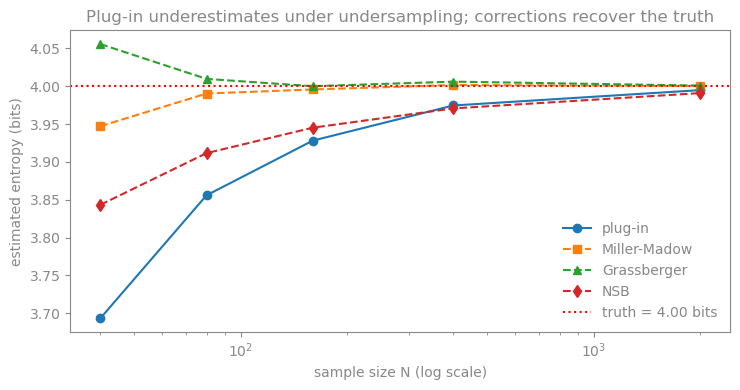

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4))
for col, style in [("plug-in", "o-"), ("Miller-Madow", "s--"),
                   ("Grassberger", "^--"), ("NSB", "d--")]:
    ax.plot(table.index, table[col], style, label=col)
ax.axhline(true_entropy, color="red", ls=":", label=f"truth = {true_entropy:.2f} bits")
ax.set_xscale("log")
ax.set_xlabel("sample size N (log scale)"); ax.set_ylabel("estimated entropy (bits)")
ax.set_title("Plug-in underestimates under undersampling; corrections recover the truth")
ax.legend()
plt.tight_layout(); plt.show()

## 4. When the correction barely matters: a coarse alphabet

The bias scales with the alphabet size. For a **binary** encoding ($K=2$, e.g.
up/down moves) the plug-in is already close to the truth, so the correction buys
almost nothing. The gain from bias correction is largest exactly when the encoding
is fine and the sample is short.

In [6]:
for N in (40, 200):
    msgs = [random_message(2, N, seed=s) for s in range(12)]
    pi  = np.mean([plug_in_entropy_estimator(m) for m in msgs])
    nsb = np.mean([nsb_entropy(m, alphabet_size=2) for m in msgs])
    print(f"binary, N={N:4d}:  plug-in = {pi:.3f}   NSB = {nsb:.3f}   (truth = 1.000 bit)")

binary, N=  40:  plug-in = 0.977   NSB = 0.966   (truth = 1.000 bit)
binary, N= 200:  plug-in = 0.997   NSB = 0.994   (truth = 1.000 bit)


## Takeaways

- The **plug-in** entropy underestimates by about $-(K-1)/(2N)$: prefer a
  **bias-corrected estimator whenever the symbol counts are undersampled** (a large
  effective alphabet relative to the sample, e.g. long words, fine encodings, or
  short windows).
- **NSB** is most accurate in deep undersampling; **Grassberger** is close at lower
  cost (the practical default when undersampled); **Miller-Madow** is the cheap
  first-order fix. All converge to the plug-in when $N \gg K$ with no
  over-correction, so a correction is a safe default and the plug-in is fine when
  well-sampled.
- The gain is **negligible for coarse encodings** (e.g. binary), and a gap caused
  by non-stationarity is not an entropy-bias problem a correction can fix.

All estimators come from `RiskLabAI.features.entropy_features`.